## ICA review example

NBL020: this one has weirdly low EOG correlation, despite looking almost identical visually. I ran a rolling-window correlation between IC000 and EOG and it seems like the low correlation is driven by long periods of inactivity on the EOG channel -- we had to tape corrective lenses to this participant's face, so maybe he just wasn't blinking as much as is normal? Or did an EOG lead come off? Particularly in the middle of the experiment there's not much activity at all on EOG.

I would reject IC000 for ocular artifact and IC014 for cardiac artifact.

In [1]:
# load packages
import numpy as np
import os
import time
import mne
from mne.io import read_raw_fif
from mne.preprocessing import ICA, read_ica
%matplotlib inline

In [2]:
# filter params
filt_l, filt_h = 1, 200
filt_notch = 60

# ICA params
decim = 5
reject = dict(mag=5e-12, grad=4e-10)
random_state = 42
max_iter = 10000

In [5]:
# subject info
subject = 'nbl_020'
session = '01'

# file paths
meg_dir = os.path.join('/mnt/sphere/nbl/processed_meg/', subject, 'ses-'+session)
raw_fname = os.path.join(meg_dir, f"{subject}_ALL_sss_raw.fif")
er_fname = os.path.join(meg_dir, f"{subject}_emptyroom_sss_raw.fif")
bads_list_fname = os.path.join(meg_dir, f"{subject}_bads.txt")
ica_solution_fname = os.path.join(meg_dir, f"{subject}_ALL-ica.fif")
ica_processed_fname = os.path.join(meg_dir, f"{subject}_ALL_post_ica-raw.fif")

if not os.path.exists(bads_list_fname):
    raise FileNotFoundError(f"Bad channels file not found: {bads_list_fname}. Go back and make it.")
with open(bads_list_fname, 'r') as f: bads = [line.strip() for line in f.readlines()]

In [6]:
## load in raw data, remove bad channels, and load in ICA solution
print(f"Reading raw file for {subject}...")
t = time.time()
raw = read_raw_fif(raw_fname, preload=True, verbose=True)
elapsed_readraw = time.time() - t
print(f"Loaded in {elapsed_readraw:.1f} seconds.\n")

print("Excluding bad channels...")
raw.info['bads'] = bads
print('Bad channels:', bads)
raw.pick(picks='all', exclude='bads')
raw.info.normalize_proj()

print("\nFiltering data...")
raw = raw.filter(filt_l, filt_h, picks='meg', n_jobs=-1)
raw = raw.notch_filter(filt_notch, picks='meg', n_jobs=-1)

Reading raw file for nbl_020...
Opening raw data file /mnt/sphere/nbl/processed_meg/nbl_020/ses-01/nbl_020_ALL_sss_raw.fif...
    Range : 120000 ... 1780999 =    120.000 ...  1780.999 secs
Ready.
Opening raw data file /mnt/sphere/nbl/processed_meg/nbl_020/ses-01/nbl_020_ALL_sss_raw-1.fif...
    Range : 1781000 ... 3441999 =   1781.000 ...  3441.999 secs
Ready.
Opening raw data file /mnt/sphere/nbl/processed_meg/nbl_020/ses-01/nbl_020_ALL_sss_raw-2.fif...
    Range : 3442000 ... 5102999 =   3442.000 ...  5102.999 secs
Ready.
Opening raw data file /mnt/sphere/nbl/processed_meg/nbl_020/ses-01/nbl_020_ALL_sss_raw-3.fif...
    Range : 5103000 ... 5635999 =   5103.000 ...  5635.999 secs
Ready.
Reading 0 ... 5515999  =      0.000 ...  5515.999 secs...
Loaded in 109.8 seconds.

Excluding bad channels...
Bad channels: ['MEG1132', 'MEG1843', 'MEG1543']

Filtering data...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 1 - 2e+02 Hz

FIR filter parameters
-------------

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed:   18.4s
[Parallel(n_jobs=-1)]: Done 303 out of 303 | elapsed:   21.4s finished


Filtering raw data in 3 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 303 out of 303 | elapsed:   21.5s finished


Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed:   16.1s
[Parallel(n_jobs=-1)]: Done 303 out of 303 | elapsed:   19.1s finished


Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 303 out of 303 | elapsed:   18.0s finished


In [7]:
print ("\nReading ICA solution...")
ica = read_ica(ica_solution_fname)


Reading ICA solution...
Reading /mnt/sphere/nbl/processed_meg/nbl_020/ses-01/nbl_020_ALL-ica.fif ...
Now restoring ICA solution ...
Ready.


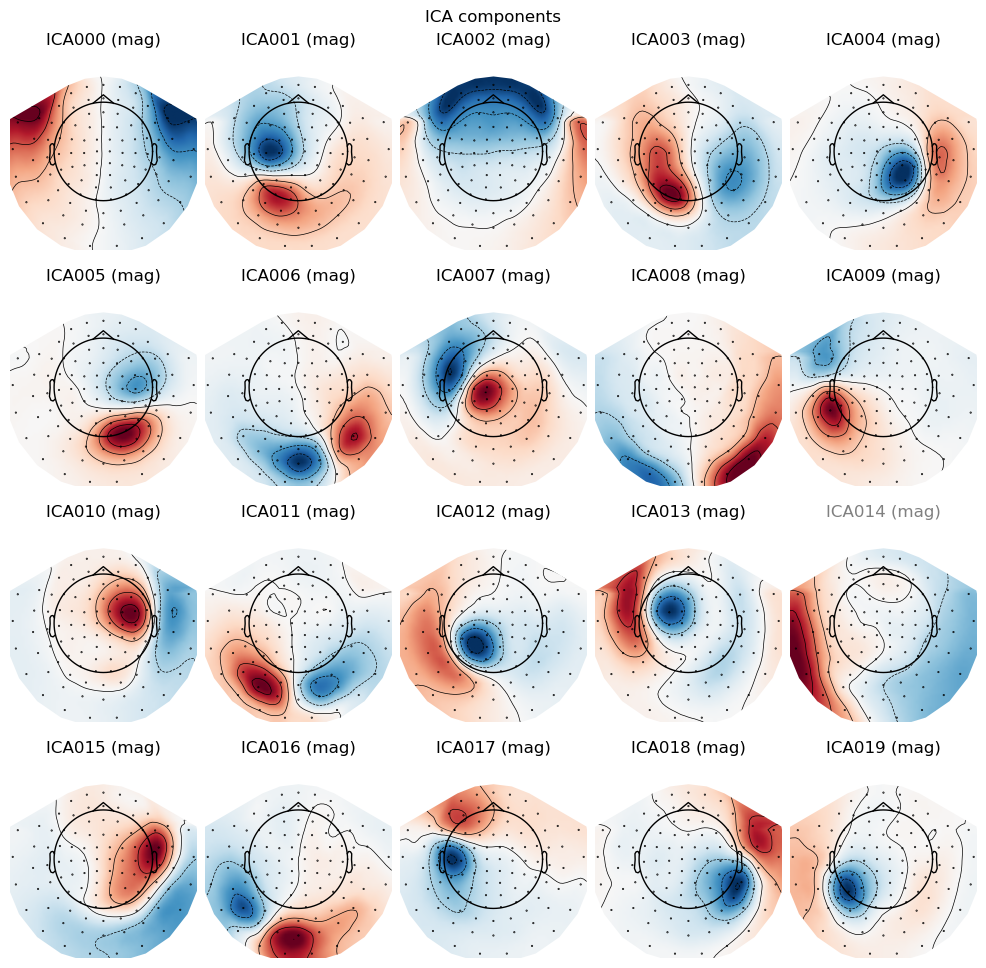

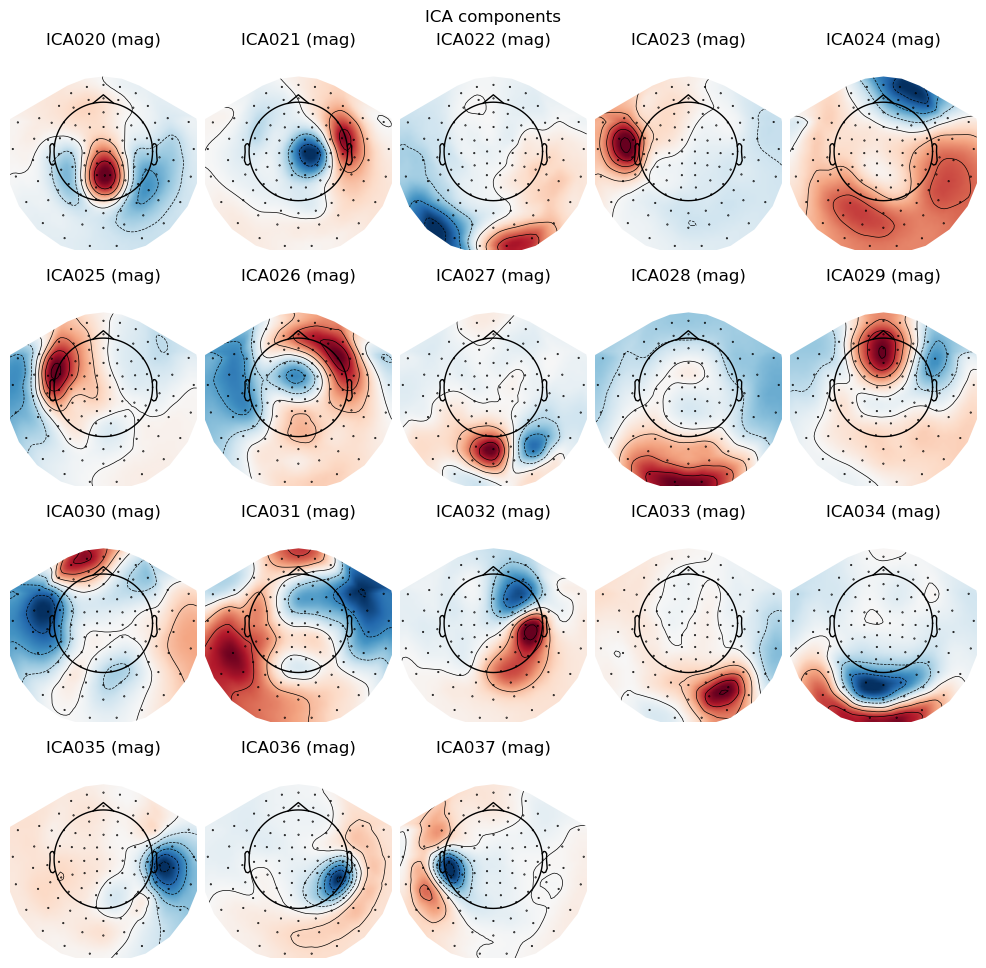

In [8]:
# plot components of the ICA
ica.plot_components();

In [9]:
# EOG and ECG adjustments
print("Finding EOG scores...")
eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name='EOG001', measure='correlation', threshold=0.5)
print("Finding ECG scores...")
ecg_indices, ecg_scores = ica.find_bads_ecg(raw, ch_name='ECG002', measure='correlation', threshold=0.5)

Finding EOG scores...
Using EOG channel: EOG001
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cuto

In [10]:
print('Identified EOG comps:', eog_indices)
print('Identified ECG comps:', ecg_indices)
ica.exclude = eog_indices + ecg_indices

Identified EOG comps: []
Identified ECG comps: [np.int64(14)]


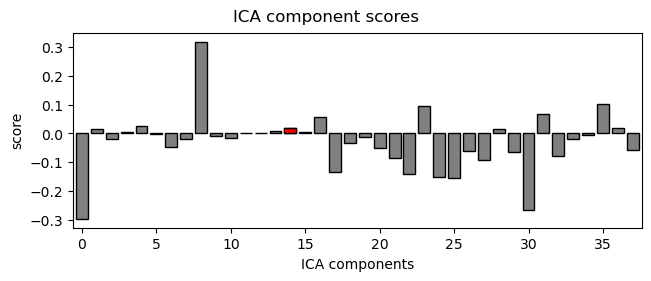

In [11]:
# EOG checks: barplot of ICA component "EOG match" scores
ica.plot_scores(eog_scores);

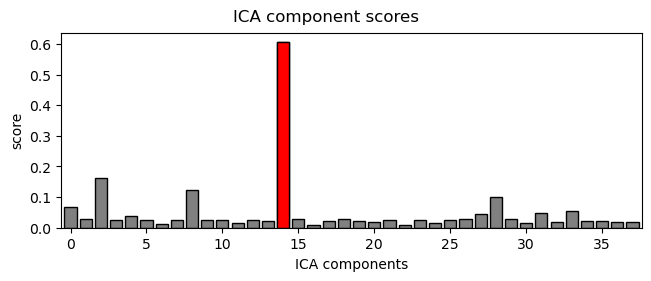

In [12]:
# ECG checks: barplot of ICA component "ECG match" scores
ica.plot_scores(ecg_scores);

Applying ICA to Raw instance
    Transforming to ICA space (38 components)
    Zeroing out 1 ICA component
    Projecting back using 303 PCA components


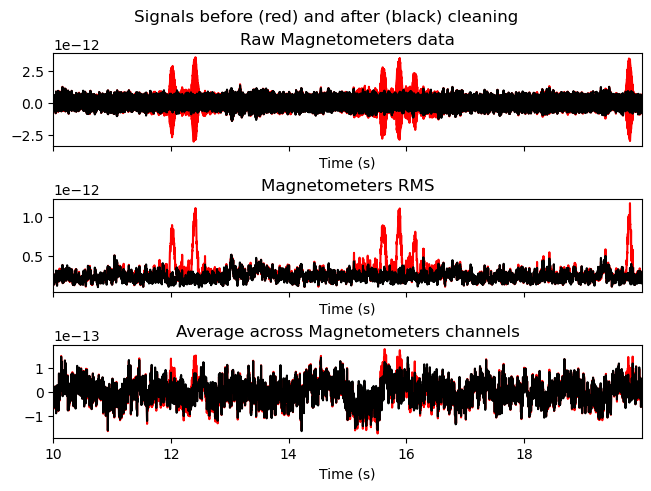

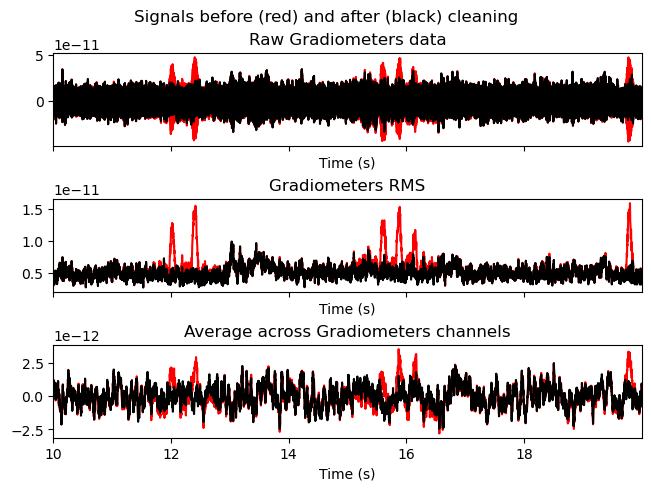

In [13]:
# blinks
ica.exclude = []
eog_indices = [0]
ica.plot_overlay(raw, exclude=eog_indices, picks="meg", start=10.0, stop=20.0);

Applying ICA to Raw instance
    Transforming to ICA space (38 components)
    Zeroing out 1 ICA component
    Projecting back using 303 PCA components


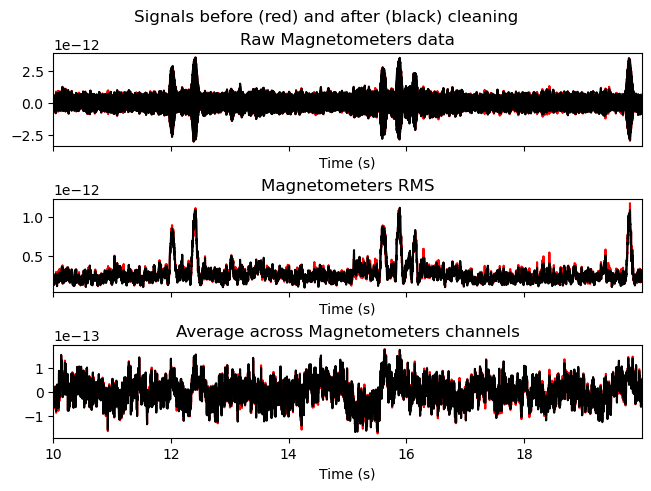

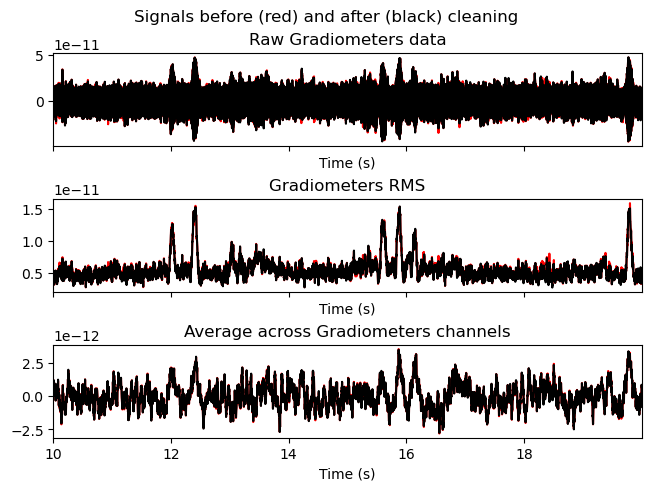

In [14]:
# heartbeats
ecg_indices = [14]
ica.plot_overlay(raw, exclude=ecg_indices, picks="meg", start=10.0, stop=20.0);

In [15]:
# write final exclusions to ICA solution
ica.exclude = eog_indices + ecg_indices
ica.save(ica_solution_fname, overwrite=True)  # save solution with edited exclusions
reconst_raw = raw.copy()
ica.apply(reconst_raw)

Overwriting existing file.
Writing ICA solution to /mnt/sphere/nbl/processed_meg/nbl_013/ses-01/nbl_013_ALL-ica.fif...
Overwriting existing file.
Applying ICA to Raw instance
    Transforming to ICA space (33 components)
    Zeroing out 3 ICA components
    Projecting back using 303 PCA components


<Raw | nbl_013_ALL_sss_raw.fif, 319 x 5159000 (5159.0 s), ~12.27 GiB, data loaded>

In [24]:
sources = ica.get_sources(raw)
sources_data = sources.get_data()
print(f"Sources duration: {sources.times[-1]:.2f} seconds")

Sources duration: 1661.00 seconds


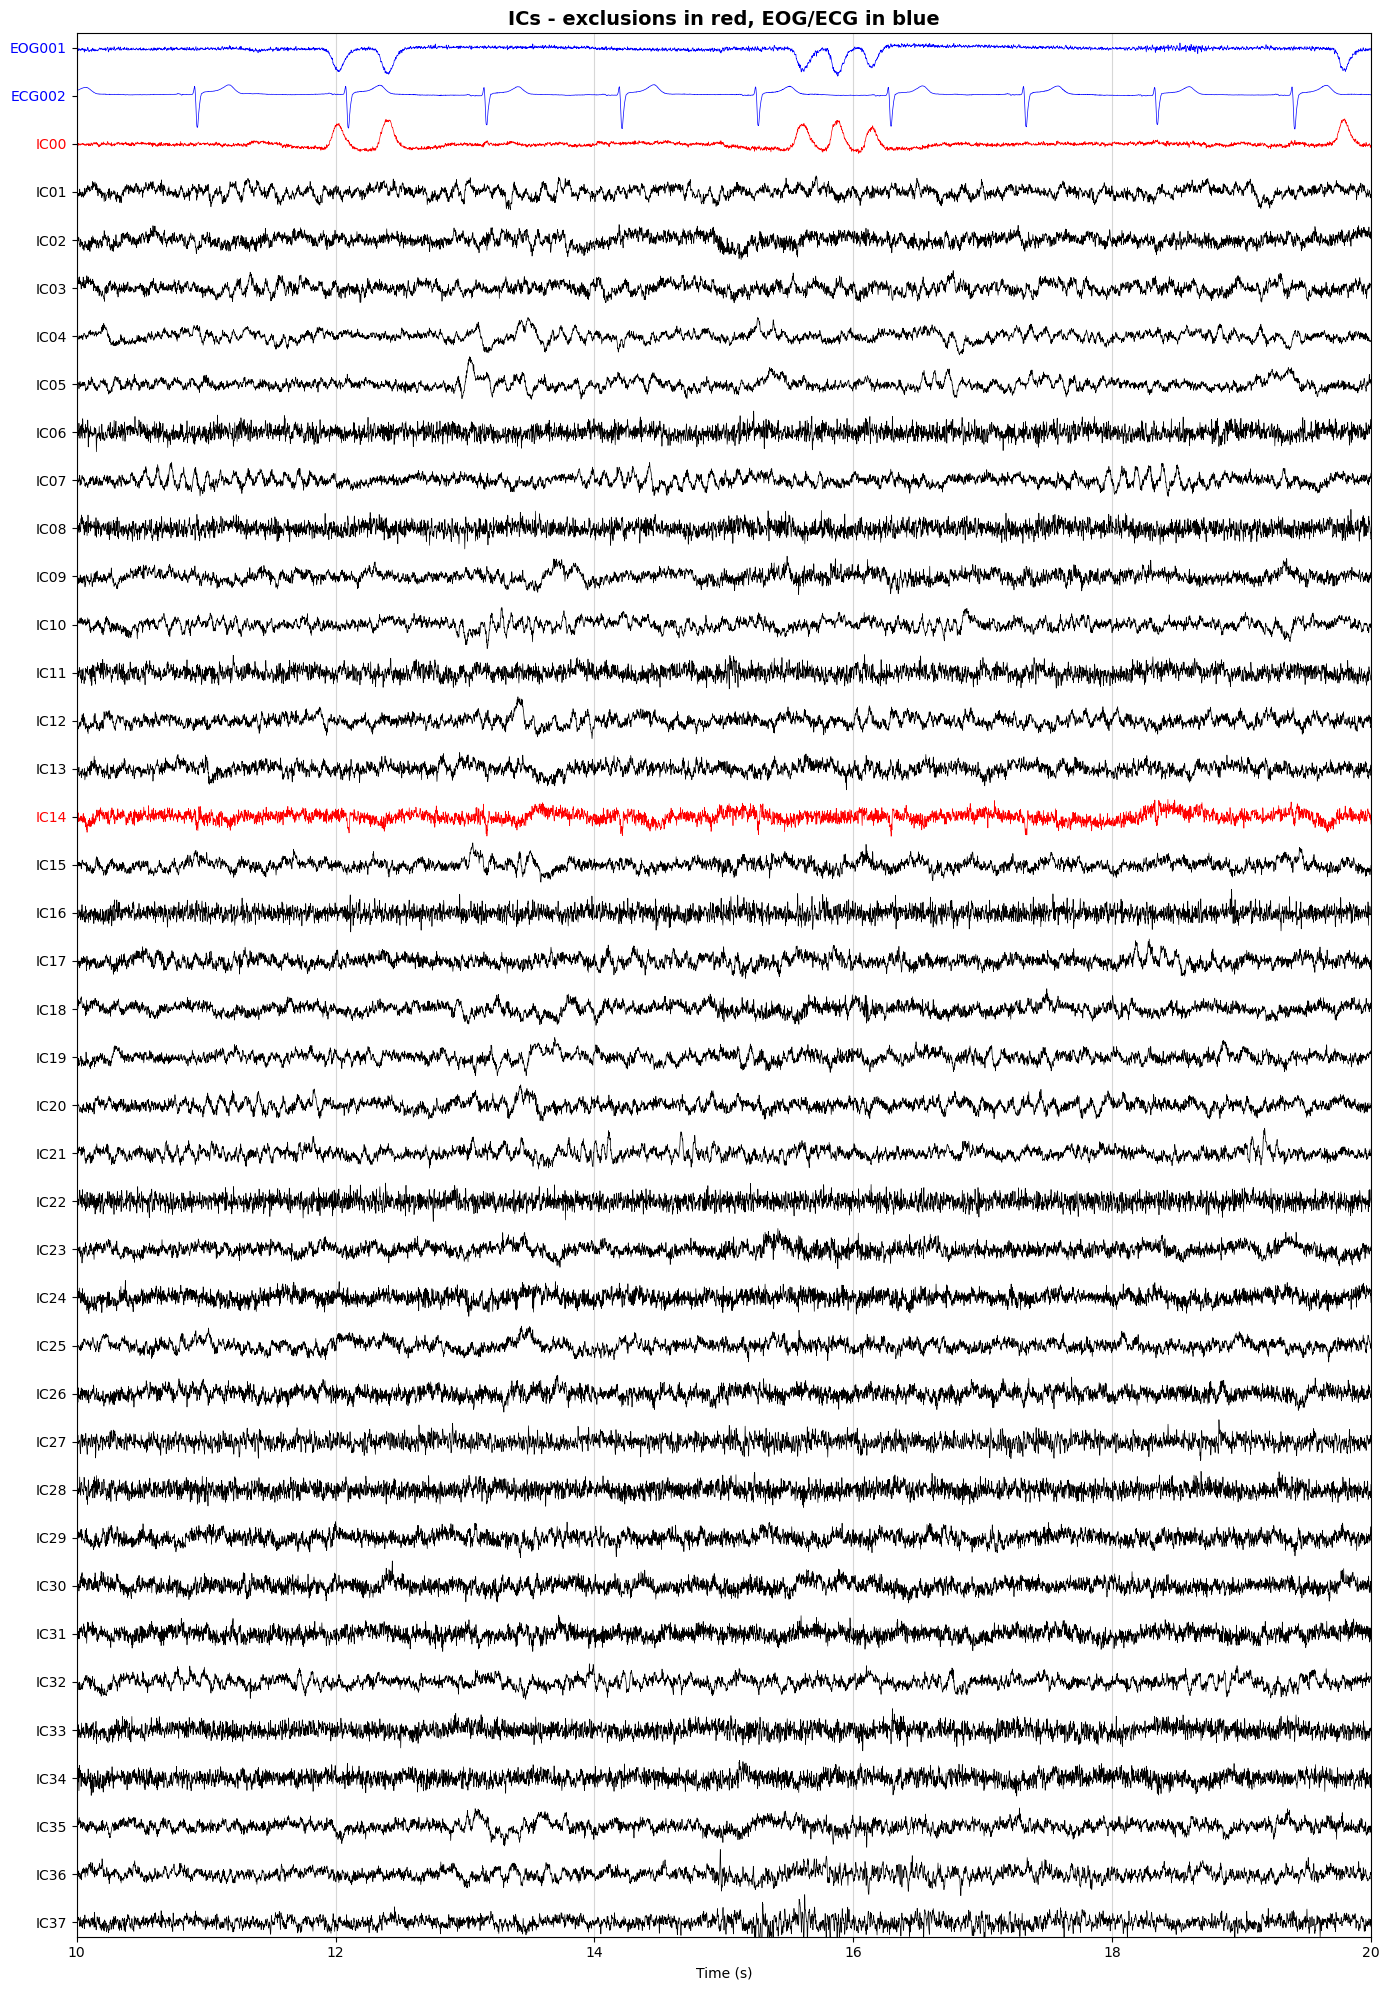

In [25]:
# plot ICs with exclusions in red
import matplotlib.pyplot as plt

sources = ica.get_sources(raw)
start_s = 10  # seconds
duration = 10  # seconds
sfreq = raw.info['sfreq']
start_sample = int(start_s * sfreq)
n_samples = int(duration * sfreq)

ica_data = sources.get_data()[:, start_sample:start_sample+n_samples]
times = sources.times[start_sample:start_sample+n_samples]

# get EOG and ECG channels
eog_channels = [ch for ch in raw.ch_names if 'EOG' in ch.upper()]
ecg_channels = [ch for ch in raw.ch_names if 'ECG' in ch.upper()]
aux_channels = eog_channels + ecg_channels
aux_data = []
aux_labels = []
for ch in aux_channels:
    ch_data = raw.copy().pick(ch).get_data()[:, start_sample:start_sample+n_samples][0]
    aux_data.append(ch_data)
    aux_labels.append(ch)
aux_data = np.array(aux_data)

# combine all channels
n_ics, n_aux = ica_data.shape[0], aux_data.shape[0]
all_data = []
all_labels = []
all_data.append(aux_data)
all_labels.extend(aux_labels)
all_data.append(ica_data)
all_labels.extend([f'IC{i:02d}' for i in range(n_ics)])

all_data = np.vstack(all_data)
data_norm = all_data / np.std(all_data, axis=1, keepdims=True)
offsets = np.arange(n_aux + n_ics)[:, np.newaxis] * 10
data_plot = data_norm + offsets

fig, ax = plt.subplots(figsize=(14, 20))
for idx in range(n_aux):
    ax.plot(times, data_plot[idx], color='blue', linewidth=0.5)
for idx in range(n_ics):
    plot_idx = n_aux + idx
    color = 'red' if idx in ica.exclude else 'black'
    ax.plot(times, data_plot[plot_idx], color=color, linewidth=0.5)
ax.set_yticks(offsets[:, 0])
ax.set_yticklabels(all_labels)

for idx, label in enumerate(ax.get_yticklabels()):
    if idx < n_aux:
        label.set_color('blue')
    elif (idx - n_aux) in ica.exclude:
        label.set_color('red')

ax.set_xlim([start_s, start_s+duration])
ax.set_ylim([offsets[-1, 0] + 3, offsets[0, 0] - 3])
ax.set_xlabel('Time (s)')
ax.set_title('ICs - exclusions in red, EOG/ECG in blue', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

Overall |correlation|: 0.892
Mean rolling |correlation|: 0.591
Std rolling |correlation|: 0.404


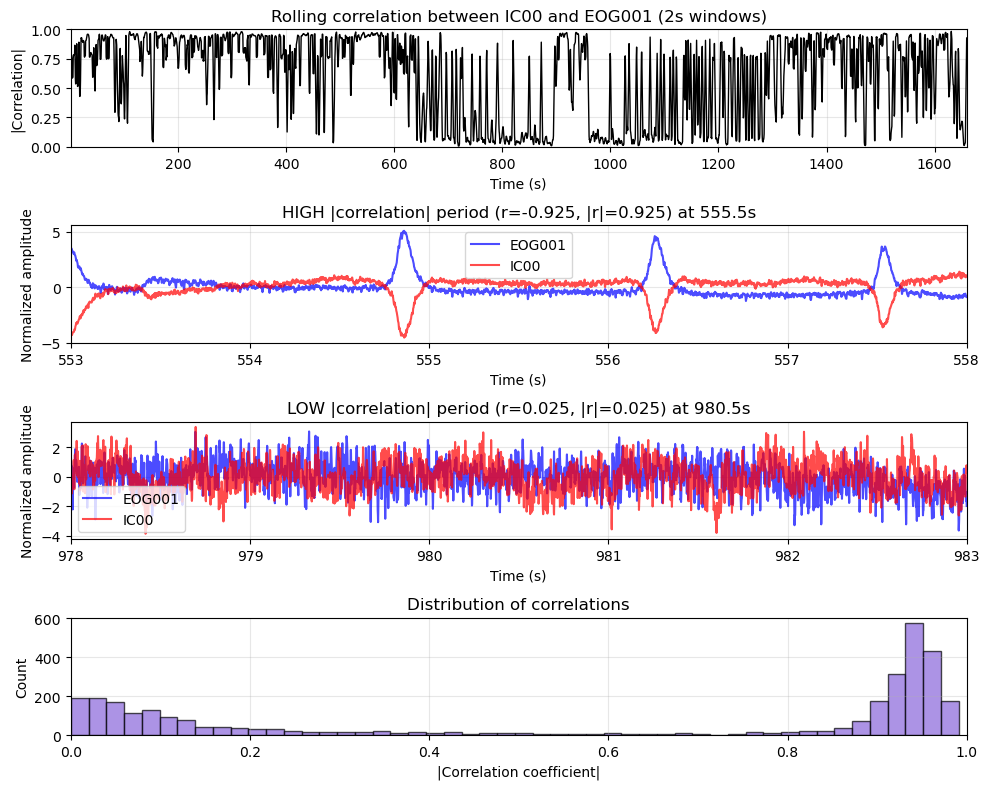

In [40]:
# trying to figure out why IC000 has such a low correlation with EOG
from scipy import signal
from scipy.stats import pearsonr

sources = ica.get_sources(raw)
ic_idx = 0
eog_ch = 'EOG001'
ic_data = sources.get_data()[ic_idx, :]
eog_data = raw.copy().pick(eog_ch).get_data()[0, :len(ic_data)]  # match length
times = sources.times
sfreq = raw.info['sfreq']

# rolling correlation
window_duration = 2
window_samples = int(window_duration * sfreq)
hop_samples = int(0.5 * sfreq)
correlations = []
correlations_abs = []
correlation_times = []

for i in range(0, len(ic_data) - window_samples, hop_samples):
    window_ic = ic_data[i:i+window_samples]
    window_eog = eog_data[i:i+window_samples]
    corr, _ = pearsonr(window_ic, window_eog)
    correlations.append(corr)
    correlations_abs.append(np.abs(corr))
    correlation_times.append(times[i + window_samples//2])

correlations = np.array(correlations)
correlations_abs = np.array(correlations_abs)
correlation_times = np.array(correlation_times)

corr_threshold_high = np.percentile(correlations_abs, 75)
corr_threshold_low = np.percentile(correlations_abs, 25)
high_corr_mask = correlations_abs > corr_threshold_high
low_corr_mask = correlations_abs < corr_threshold_low
high_corr_times = correlation_times[high_corr_mask]
low_corr_times = correlation_times[low_corr_mask]

print(f"Overall |correlation|: {np.abs(np.corrcoef(ic_data, eog_data)[0,1]):.3f}")
print(f"Mean rolling |correlation|: {np.mean(correlations_abs):.3f}")
print(f"Std rolling |correlation|: {np.std(correlations_abs):.3f}")

fig, axes = plt.subplots(4, 1, figsize=(10, 8))

ax = axes[0]
from scipy.ndimage import uniform_filter1d
correlations_abs_smooth = uniform_filter1d(correlations_abs, size=5, mode='nearest')
ax.plot(correlation_times, correlations_abs_smooth, linewidth=1, color='black')
ax.set_ylabel('|Correlation|')
ax.set_xlabel('Time (s)')
ax.set_ylim([0, 1])
ax.set_xlim([correlation_times[0], correlation_times[-1]])
ax.set_title(f'Rolling correlation between IC{ic_idx:02d} and {eog_ch} ({window_duration}s windows)')
ax.grid(True, alpha=0.3)

example_high_time = high_corr_times[len(high_corr_times)//2]
plot_duration = 5  # seconds
plot_start = max(0, example_high_time - plot_duration/2)
plot_end = min(times[-1], example_high_time + plot_duration/2)

plot_mask = (times >= plot_start) & (times <= plot_end)
plot_times = times[plot_mask]
plot_ic = ic_data[plot_mask]
plot_eog = eog_data[plot_mask]
plot_ic_norm = (plot_ic - np.mean(plot_ic)) / np.std(plot_ic)
plot_eog_norm = (plot_eog - np.mean(plot_eog)) / np.std(plot_eog)

local_corr = np.corrcoef(plot_ic, plot_eog)[0,1]

ax = axes[1]
ax.plot(plot_times, plot_eog_norm, label=eog_ch, color='blue', linewidth=1.5, alpha=0.7)
ax.plot(plot_times, plot_ic_norm, label=f'IC{ic_idx:02d}', color='red', linewidth=1.5, alpha=0.7)
ax.set_ylabel('Normalized amplitude')
ax.set_xlabel('Time (s)')
ax.set_xlim([plot_times[0], plot_times[-1]])
ax.set_title(f'HIGH |correlation| period (r={local_corr:.3f}, |r|={np.abs(local_corr):.3f}) at {example_high_time:.1f}s')
ax.legend()
ax.grid(True, alpha=0.3)

example_low_time = low_corr_times[len(low_corr_times)//2]
plot_duration = 5  # seconds
plot_start = max(0, example_low_time - plot_duration/2)
plot_end = min(times[-1], example_low_time + plot_duration/2)

plot_mask = (times >= plot_start) & (times <= plot_end)
plot_times = times[plot_mask]
plot_ic = ic_data[plot_mask]
plot_eog = eog_data[plot_mask]
plot_ic_norm = (plot_ic - np.mean(plot_ic)) / np.std(plot_ic)
plot_eog_norm = (plot_eog - np.mean(plot_eog)) / np.std(plot_eog)

local_corr = np.corrcoef(plot_ic, plot_eog)[0,1]

ax = axes[2]
ax.plot(plot_times, plot_eog_norm, label=eog_ch, color='blue', linewidth=1.5, alpha=0.7)
ax.plot(plot_times, plot_ic_norm, label=f'IC{ic_idx:02d}', color='red', linewidth=1.5, alpha=0.7)
ax.set_ylabel('Normalized amplitude')
ax.set_xlabel('Time (s)')
ax.set_xlim([plot_times[0], plot_times[-1]])
ax.set_title(f'LOW |correlation| period (r={local_corr:.3f}, |r|={np.abs(local_corr):.3f}) at {example_low_time:.1f}s')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[3]
ax.hist(correlations_abs, bins=50, color='#8966db', alpha=0.7, edgecolor='black')
ax.set_xlabel('|Correlation coefficient|')
ax.set_ylabel('Count')
ax.set_xlim([0, 1])
ax.set_title('Distribution of correlations')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

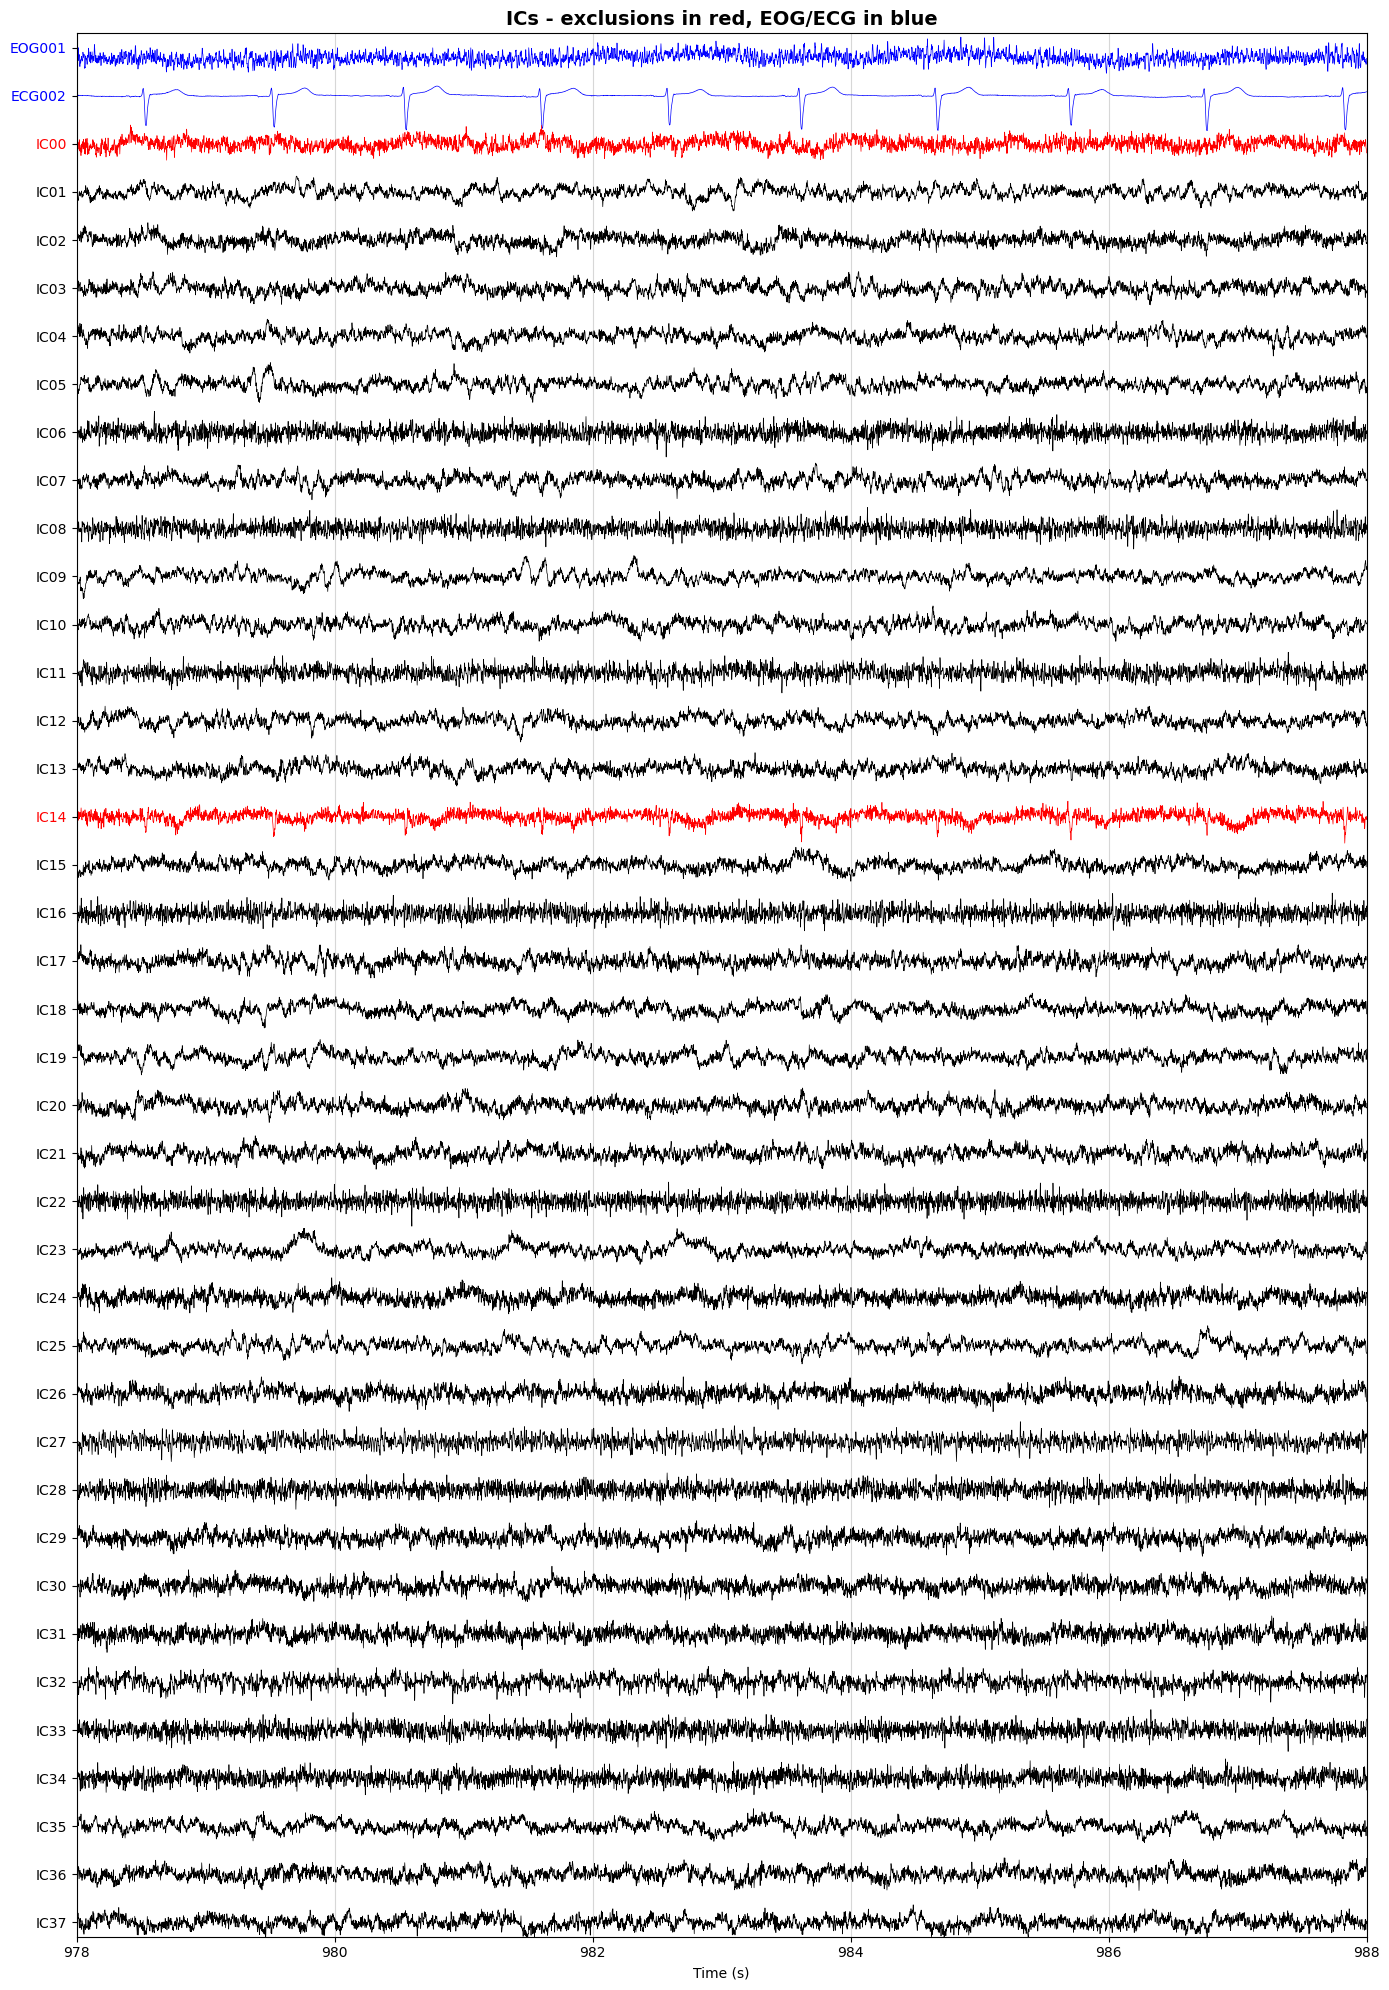

In [32]:
# plot ICs with exclusions in red
import matplotlib.pyplot as plt

sources = ica.get_sources(raw)
start_s = 978  # seconds
duration = 10  # seconds
sfreq = raw.info['sfreq']
start_sample = int(start_s * sfreq)
n_samples = int(duration * sfreq)

ica_data = sources.get_data()[:, start_sample:start_sample+n_samples]
times = sources.times[start_sample:start_sample+n_samples]

# get EOG and ECG channels
eog_channels = [ch for ch in raw.ch_names if 'EOG' in ch.upper()]
ecg_channels = [ch for ch in raw.ch_names if 'ECG' in ch.upper()]
aux_channels = eog_channels + ecg_channels
aux_data = []
aux_labels = []
for ch in aux_channels:
    ch_data = raw.copy().pick(ch).get_data()[:, start_sample:start_sample+n_samples][0]
    aux_data.append(ch_data)
    aux_labels.append(ch)
aux_data = np.array(aux_data)

# combine all channels
n_ics, n_aux = ica_data.shape[0], aux_data.shape[0]
all_data = []
all_labels = []
all_data.append(aux_data)
all_labels.extend(aux_labels)
all_data.append(ica_data)
all_labels.extend([f'IC{i:02d}' for i in range(n_ics)])

all_data = np.vstack(all_data)
data_norm = all_data / np.std(all_data, axis=1, keepdims=True)
offsets = np.arange(n_aux + n_ics)[:, np.newaxis] * 10
data_plot = data_norm + offsets

fig, ax = plt.subplots(figsize=(14, 20))
for idx in range(n_aux):
    ax.plot(times, data_plot[idx], color='blue', linewidth=0.5)
for idx in range(n_ics):
    plot_idx = n_aux + idx
    color = 'red' if idx in ica.exclude else 'black'
    ax.plot(times, data_plot[plot_idx], color=color, linewidth=0.5)
ax.set_yticks(offsets[:, 0])
ax.set_yticklabels(all_labels)

for idx, label in enumerate(ax.get_yticklabels()):
    if idx < n_aux:
        label.set_color('blue')
    elif (idx - n_aux) in ica.exclude:
        label.set_color('red')

ax.set_xlim([start_s, start_s+duration])
ax.set_ylim([offsets[-1, 0] + 3, offsets[0, 0] - 3])
ax.set_xlabel('Time (s)')
ax.set_title('ICs - exclusions in red, EOG/ECG in blue', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

### low overall correlation seems to be driven by long periods of inactivity on the EOG channel - maybe he wasn't blinking as much because of the lenses taped to his face?

I'd exclude IC 0 as ocular artifact given how correlated it is when there IS EOG activity